In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from IPython.display import clear_output
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm, qmc

In [2]:
# Load all data
folder = Path(r'C:\Users\Dave Amin\Documents\docs-Sync\Career\2025-10 IC AI course\Modules\Capstone2\initial_data')
folder2 = Path(r'function_2')

def load_data():
    file_path_inputs =  folder / folder2 / rf"initial_inputs.npy"
    file_path_outputs = folder / folder2 / rf"initial_outputs.npy"
    X = np.load(file_path_inputs)
    Y = np.load(file_path_outputs)
    print('Initial data :','X.shape', X.shape, 'Y.shape', Y.shape)
    
    X_new_point = np.array([0.693878, 0.612245], dtype=np.float64)
    Y_new_point = np.array([0.5803577072802801], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 1 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.739205, 0.721611], dtype=np.float64)
    Y_new_point = np.array([0.5674036059707457], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 2 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.995575, 0.985505], dtype=np.float64)
    Y_new_point = np.array([0.06321191404298093], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 3 :','X.shape', X.shape, 'Y.shape', Y.shape)
    
    X_new_point = np.array([0.714914, 0.380302], dtype=np.float64)
    Y_new_point = np.array([0.44121029626335195], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 4 :','X.shape', X.shape, 'Y.shape', Y.shape)
    
    X_new_point = np.array([0.676232, 1.000000], dtype=np.float64)
    Y_new_point = np.array([0.5352271062528589], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 5 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.727492, 1.000000], dtype=np.float64)
    Y_new_point = np.array([0.6152135425731102], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 6 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.712736, 1.000000], dtype=np.float64)
    Y_new_point = np.array([0.542651368548669], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 7 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.235595, 0.565232], dtype=np.float64)
    Y_new_point = np.array([0.016179508116555042], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 8 :','X.shape', X.shape, 'Y.shape', Y.shape)
    
    X_new_point = np.array([0.731692, 1.000000], dtype=np.float64)
    Y_new_point = np.array([0.5430802019103309], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 9 :','X.shape', X.shape, 'Y.shape', Y.shape)

    X_new_point = np.array([0.722224, 1.000000], dtype=np.float64)
    Y_new_point = np.array([0.5415245369672016], dtype=np.float64)
    X = np.vstack((X, X_new_point))
    Y = np.append(Y, Y_new_point)
    print('Added week 10 :','X.shape', X.shape, 'Y.shape', Y.shape)

    # next week new values go here !!!!
  
    return X,Y

X,Y = load_data()

Initial data : X.shape (10, 2) Y.shape (10,)
Added week 1 : X.shape (11, 2) Y.shape (11,)
Added week 2 : X.shape (12, 2) Y.shape (12,)
Added week 3 : X.shape (13, 2) Y.shape (13,)
Added week 4 : X.shape (14, 2) Y.shape (14,)
Added week 5 : X.shape (15, 2) Y.shape (15,)
Added week 6 : X.shape (16, 2) Y.shape (16,)
Added week 7 : X.shape (17, 2) Y.shape (17,)
Added week 8 : X.shape (18, 2) Y.shape (18,)
Added week 9 : X.shape (19, 2) Y.shape (19,)
Added week 10 : X.shape (20, 2) Y.shape (20,)


In [3]:
print('X.shape', X.shape)
print('X col1 min',np.min(X[:, 0]), 'max',np.max(X[:, 0]))
print('X col2 min',np.min(X[:, 1]), 'max',np.max(X[:, 1]))
print('Y.shape', Y.shape)
print("Min Y =",min(Y),"Max Y =",max(Y))

X.shape (20, 2)
X col1 min 0.14269907423594608 max 0.995575
X col2 min 0.028697719822277867 max 1.0
Y.shape (20,)
Min Y = -0.06562362443733738 Max Y = 0.6152135425731102


In [4]:
print("X",X)
print("Y",Y)

X [[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.693878   0.612245  ]
 [0.739205   0.721611  ]
 [0.995575   0.985505  ]
 [0.714914   0.380302  ]
 [0.676232   1.        ]
 [0.727492   1.        ]
 [0.712736   1.        ]
 [0.235595   0.565232  ]
 [0.731692   1.        ]
 [0.722224   1.        ]]
Y [ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522  0.58035771  0.56740361
  0.06321191  0.4412103   0.53522711  0.61521354  0.54265137  0.01617951
  0.5430802   0.54152454]


In [5]:
def heat_scatter(X,Y):
    plt.figure(figsize=(10, 7))
    
    # We use SymLogNorm because your data has negatives and extremely small positives
    norm = colors.SymLogNorm(linthresh=1e-20, linscale=1, vmin=Y.min(), vmax=Y.max())
    
    scatter = plt.scatter(X[:, 0], X[:, 1], c=Y, s=200, edgecolors='black', 
                          cmap='RdYlBu', norm=norm)
    
    # Add labels for each point's order (1 to 10)
    for i, txt in enumerate(range(1, len(Y) + 1)):
        plt.annotate(txt, (X[i, 0]+0.02, X[i, 1]+0.02))
    plt.colorbar(scatter, label='Y value (Symmetric Log Scale)')
    plt.xlabel('Input Feature 1 ($x_1$)')
    plt.ylabel('Input Feature 2 ($x_2$)')
    plt.title('Contest Data: Sample Locations and Observations')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

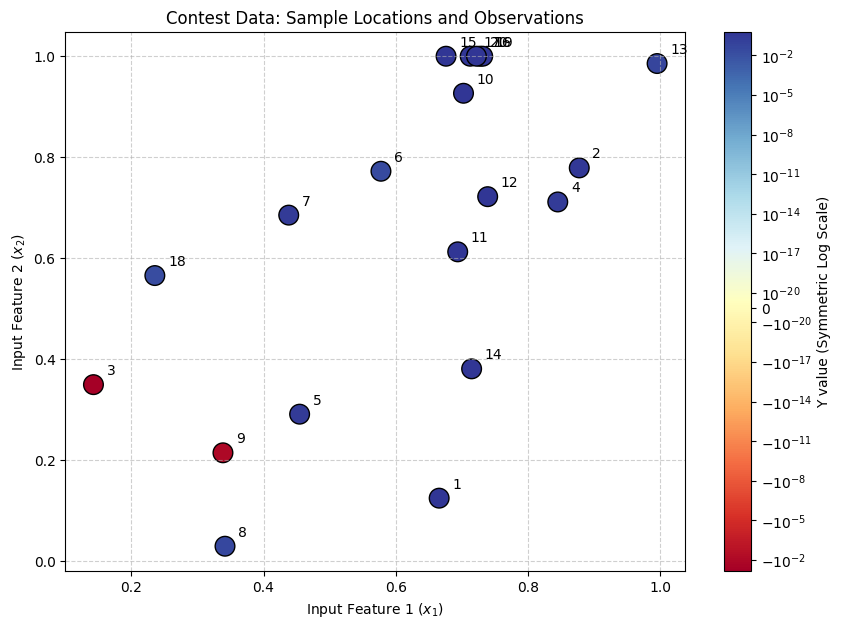

In [6]:
heat_scatter(X,Y)

In [7]:
# def plot3Dprediction(X,Y,model):
#     import numpy as np
#     import matplotlib.pyplot as plt
#     from matplotlib import cm
    
#     # 1. Determine the bounds of your loaded data for the grid
#     # 2. Create a dense grid for predictions
#     # We use 50x50 points to create a smooth surface
#     x1_linspace = np.linspace(0, 1, 50)
#     x2_linspace = np.linspace(0, 1, 50)
#     X1_grid, X2_grid = np.meshgrid(x1_linspace, x2_linspace)
    
#     # Flatten the grid to feed into the model
#     x_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])
    
#     # 3. Predict using your fitted model
#     y_pred, std = model.predict(x_test, return_std=True)
    
#     # Reshape predictions back into the grid shape for plotting
#     Z_mean = y_pred.reshape(X1_grid.shape)
#     Z_std = std.reshape(X1_grid.shape)
    
#     # 4. Create the Visualization
#     fig = plt.figure(figsize=(16, 6))
    
#     # --- Subplot 1: 3D Surface of Predicted Mean ---
#     ax1 = fig.add_subplot(121, projection='3d')
#     surf = ax1.plot_surface(X1_grid, X2_grid, Z_mean, cmap='viridis', alpha=0.8, edgecolor='none')
#     ax1.scatter(X[:, 0], X[:, 1], Y, color='red', marker='x', s=50, label='Actual Data')
#     ax1.set_title('GP Predicted Mean Surface')
#     ax1.set_zlabel('Output Y')
#     fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
    
#     # --- Subplot 2: Heatmap of Uncertainty (Std Dev) ---
#     ax2 = fig.add_subplot(122)
#     contour = ax2.contourf(X1_grid, X2_grid, Z_std, levels=20, cmap='YlOrRd')
#     # contour = ax2.contourf(X1_grid, X2_grid, Z_mean, levels=20, cmap='YlOrRd')
#     ax2.scatter(X[:, 0], X[:, 1], c='black', marker='+', alpha=0.5)
#     ax2.set_title('Model Uncertainty (Std Dev)')
#     ax2.set_xlabel('Input Feature 1')
#     ax2.set_ylabel('Input Feature 2')
#     fig.colorbar(contour, ax=ax2, label='Standard Deviation')
    
#     plt.tight_layout()
#     plt.show()

In [8]:
def plot3Dprediction2(X,Y, y_pred, std, X1_grid, X2_grid):
    # Reshape predictions back into the grid shape for plotting
    Z_mean = y_pred.reshape(X1_grid.shape)
    Z_std = std.reshape(X1_grid.shape)
    
    # 4. Create the Visualization
    fig = plt.figure(figsize=(16, 6))
    
    # --- Subplot 1: 3D Surface of Predicted Mean ---
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(X1_grid, X2_grid, Z_mean, cmap='viridis', alpha=0.8, edgecolor='none')
    ax1.scatter(X[:, 0], X[:, 1], Y, color='red', marker='x', s=50, label='Actual Data')
    ax1.set_title('GP Predicted Mean Surface')
    ax1.set_zlabel('Output Y')
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)
    
    # --- Subplot 2: Heatmap of Uncertainty (Std Dev) ---
    ax2 = fig.add_subplot(122)
    contour = ax2.contourf(X1_grid, X2_grid, Z_std, levels=20, cmap='YlOrRd')
    # contour = ax2.contourf(X1_grid, X2_grid, Z_mean, levels=20, cmap='YlOrRd')
    ax2.scatter(X[:, 0], X[:, 1], c='black', marker='+', alpha=0.5)
    ax2.set_title('Model Uncertainty (Std Dev)')
    ax2.set_xlabel('Input Feature 1')
    ax2.set_ylabel('Input Feature 2')
    fig.colorbar(contour, ax=ax2, label='Standard Deviation')
    
    plt.tight_layout()
    plt.show()

In [9]:
def plot_2d_uncertainty(model, X_train, next_point, bounds=[(0, 1), (0, 1)]):
    # 1. Create a 2D meshgrid
    res = 100 
    x1 = np.linspace(bounds[0][0], bounds[0][1], res)
    x2 = np.linspace(bounds[1][0], bounds[1][1], res)
    X1, X2 = np.meshgrid(x1, x2)
    grid = np.vstack([X1.ravel(), X2.ravel()]).T
    
    # 2. Get uncertainty (sigma)
    _, sigma = model.predict(grid, return_std=True)
    Sigma = sigma.reshape(X1.shape)
    
    # 3. Setup Plot
    plt.figure(figsize=(8, 6))
    
    # Plot the uncertainty background
    contour = plt.contourf(X1, X2, Sigma, levels=20, cmap='viridis', alpha=0.8)
    plt.colorbar(contour, label='Uncertainty (Sigma)')
    
    # 4. Plot PREVIOUS samples (Red Circles)
    plt.scatter(X_train[:, 0], X_train[:, 1], color='red', edgecolors='white', 
                label='Sampled Points', s=60)
    
    # 5. Plot the NEXT proposed point (Lime Star)
    plt.scatter(next_point[0], next_point[1], color='lime', marker='*', s=300, 
                edgecolors='black', label='Next Point (res.x)', zorder=5)
    
    plt.title("Model Uncertainty and Next Suggested Point")
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.legend()
    for i, txt in enumerate(range(1, len(Y) + 1)):
        plt.annotate(txt, (X[i, 0]+0.02, X[i, 1]+0.02))
    plt.show()

# --- Execution ---
# plot_2d_uncertainty(model, X, next-point)

In [10]:
def plot_acquisition_surface(model, beta=1.96):
    # 1. Create the grid
    res = 50
    x1 = np.linspace(0, 1, res)
    x2 = np.linspace(0, 1, res)
    X1, X2 = np.meshgrid(x1, x2)
    grid = np.column_stack([X1.ravel(), X2.ravel()])

    # 2. Get predictions
    mean, std = model.predict(grid, return_std=True)
    acq = mean + beta * std
    Z = acq.reshape(res, res)

    # 3. Plotting
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plot the acquisition surface
    surf = ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8, edgecolor='none')
    
    # Plot the actual data points we've sampled so far
    ax.scatter(X[:, 0], X[:, 1], Y, color='red', s=50, label='Observed Data')
    
    ax.set_title(f"UCB Acquisition Surface (Beta={beta})")
    ax.set_xlabel("Input X1")
    ax.set_ylabel("Input X2")
    ax.set_zlabel("Acquisition Value")
    fig.colorbar(surf, shrink=0.5, aspect=5)
    
    plt.show()

# Call the function
# plot_acquisition_surface(model)

## New Code 23 Apr - v3 - The "Vertical Drop" Test

In [9]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

# 1. MODEL RE-FIT (Focusing on Global Structure)
kernel = C(1.0) * Matern(length_scale=[0.1, 0.2], nu=2.5) + WhiteKernel(noise_level=1e-4)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True)
model.fit(X, Y)

# 2. EVALUATING THE 'INLAND' TARGET
target_pt = np.array([[0.727273, 0.595960]])
mu, sigma = model.predict(target_pt, return_std=True)

print(f"\n" + "="*40)
print(f"--- VERTICAL DROP ANALYSIS ---")
print(f"Coordinates: 0.727273-0.595960")
print(f"Predicted Mean: {mu[0]:.6f}")
print(f"Uncertainty (Exploration Value): {sigma[0]:.6f}")
print(f"Current Best: {Y.max():.6f}")
print(f"Action: This move checks if the mountain is taller 'Inland'.")
print("="*40)


--- VERTICAL DROP ANALYSIS ---
Coordinates: 0.727273-0.595960
Predicted Mean: 0.540086
Uncertainty (Exploration Value): 0.054426
Current Best: 0.615214
Action: This move checks if the mountain is taller 'Inland'.


## New Code 23 Apr - v2 - The Global Shadow Hunter

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm

# 1. FIT THE GLOBAL MODEL
# We use a slightly larger length scale to find "Broad Mountains" elsewhere
kernel = C(1.0) * Matern(length_scale=[0.15, 0.15], nu=2.5) + WhiteKernel(noise_level=1e-4)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True)
model.fit(X, Y)

# 2. GENERATE THE HEAT MAP GRID
res = 100
x1 = np.linspace(0, 1, res)
x2 = np.linspace(0, 1, res)
X1, X2 = np.meshgrid(x1, x2)
grid = np.vstack([X1.ravel(), X2.ravel()]).T

# 3. CALCULATE PROBABILITY OF IMPROVEMENT (PI)
mu, sigma = model.predict(grid, return_std=True)
y_max = Y.max()
# We look for the probability that a point is > current record + 5%
target = y_max + 0.05
Z = (mu - target) / sigma
pi = norm.cdf(Z)

# 4. FIND THE HIGHEST "SHADOW" PEAK
# We mask out the area we've already explored (the 0.7, 1.0 corner)
mask = (grid[:, 0] > 0.6) & (grid[:, 1] > 0.6)
pi[mask] = 0 

best_idx = np.argmax(pi)
best_coord = grid[best_idx]

print(f"\n" + "="*40)
print(f"--- GLOBAL SHADOW HUNTER ---")
print(f"New Exploration Target: {best_coord[0]:.6f}-{best_coord[1]:.6f}")
print(f"Predicted Probability of Breakthrough: {pi[best_idx]*100:.2f}%")
print(f"Reasoning: Moving to the largest 'Uncertainty Hole' remaining.")
print("="*40)


--- GLOBAL SHADOW HUNTER ---
New Exploration Target: 0.727273-0.595960
Predicted Probability of Breakthrough: 8.73%
Reasoning: Moving to the largest 'Uncertainty Hole' remaining.


## New Code 23 Apr - v1 - The "Needle" Refiner

In [7]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

# 1. THE "MICROSCOPE" MODEL
# Very small length scale to respect the sharp spikes we've discovered
kernel = C(1.0) * Matern(length_scale=[0.01, 0.05], nu=2.5) + WhiteKernel(noise_level=1e-6)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)
model.fit(X, Y)

# 2. MICRO-STEPPING
# We aren't optimizing globally anymore; we are "shaving" the peak.
current_best_x1 = 0.727492
step = 0.0015 # A tiny nudge

# Let's test the immediate right flank of our best point
target_x1 = current_best_x1 + step 
target_x2 = 1.0

y_pred, y_std = model.predict(np.array([[target_x1, target_x2]]), return_std=True)

print(f"\n" + "="*40)
print(f"--- THE NEEDLE REFINER ---")
print(f"Target Submission: {target_x1:.6f}-{target_x2:.6f}")
print(f"Predicted Mean: {y_pred[0]:.6f}")
print(f"Rationale: $0.722$ failed, $0.727$ is king. Testing $0.729$.")
print("="*40)


--- THE NEEDLE REFINER ---
Target Submission: 0.728992-1.000000
Predicted Mean: 0.555659
Rationale: $0.722$ failed, $0.727$ is king. Testing $0.729$.


## New Code 10 Apr - v2 - Quadratic Vertex Finder

In [6]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. THE BRACKET DATA
# We take the three points that surround the peak
x_points = np.array([0.712736, 0.727492, 0.731692]).reshape(-1, 1)
y_points = np.array([0.542651, 0.615214, 0.543080])

# 2. FIT A PARABOLA (Degree 2)
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x_points)
model = LinearRegression().fit(x_poly, y_points)

# 3. CALCULATE THE VERTEX (The high point of the parabola)
# For y = ax^2 + bx + c, the vertex is at -b / 2a
c, b, a = model.coef_ # Note: sklearn coef_ order depends on intercept
# Using the standard formula for the vertex of a parabola
a = model.coef_[2]
b = model.coef_[1]
vertex_x = -b / (2 * a)

print(f"\n" + "="*40)
print(f"--- QUADRATIC VERTEX RESULT ---")
print(f"Target Submission: {vertex_x:.6f}-1.000000")
print(f"Logic: Mathematically centered peak between the 0.712 and 0.731 brackets.")
print("="*40)


--- QUADRATIC VERTEX RESULT ---
Target Submission: 0.722224-1.000000
Logic: Mathematically centered peak between the 0.712 and 0.731 brackets.


## New Code 10 Apr - v1 - High-Precision Apex Hunter

In [5]:
# 1. THE "ULTRA-SENSITIVE" MODEL
# We set the length scale very small (0.01) to capture the sharp "needle" peak
kernel = C(1.0) * Matern(length_scale=[0.01, 0.1], nu=2.5) + WhiteKernel(noise_level=1e-6)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)
model.fit(X, Y)

# 2. BRACKETED SEARCH
# We restrict the search to the "Inner Sanctum" between our current best points
inner_sanctum = [(0.715, 0.730), (0.99, 1.0)]

def objective(x):
    x = np.atleast_2d(x)
    mu = model.predict(x)
    return -mu[0]

res = minimize(
    objective, 
    x0=[0.722, 1.0], 
    bounds=inner_sanctum, 
    method='L-BFGS-B'
)

best_x = res.x
y_pred, y_std = model.predict(best_x.reshape(1, -1), return_std=True)

print(f"\n" + "="*40)
print(f"--- THE APEX HUNTER ---")
print(f"Target Submission: {best_x[0]:.6f}-{best_x[1]:.6f}")
print(f"Predicted Mean: {y_pred[0]:.6f}")
print(f"Logic: Solving for the vertex of the bracketed peak.")
print("="*40)


--- THE APEX HUNTER ---
Target Submission: 0.715000-1.000000
Predicted Mean: 0.564014
Logic: Solving for the vertex of the bracketed peak.


## New Code 2 Apr - v1 - The "Precision Scalpel" Strategy

In [11]:
# 1. TIGHTEN THE KERNEL (Force the model to be "less smooth")
# Decreasing length_scale for X1 makes the model more sensitive to local spikes
kernel = C(1.0) * Matern(length_scale=[0.02, 0.1], nu=2.5) + WhiteKernel(noise_level=1e-6)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-5, normalize_y=True)
model.fit(X, Y)

# 2. THE "RIGHT-FLANK" SEARCH
# We are forcing the optimizer to look BEYOND our best point to see if the ridge continues
def precision_search(x):
    x = np.atleast_2d(x)
    mu, sigma = model.predict(x, return_std=True)
    # We use pure Mean (Exploitation) because we are in the "End Game"
    return -mu[0]

# Search strictly in the "Winning Zone" but push slightly higher than 0.727
res = minimize(
    precision_search, 
    x0=[0.74, 1.0], 
    bounds=[(0.728, 0.760), (0.98, 1.0)], 
    method='L-BFGS-B'
)

best_x = res.x
y_pred, _ = model.predict(best_x.reshape(1, -1), return_std=True)

print(f"\n" + "="*40)
print(f"--- PRECISION PEAK RECOVERY ---")
print(f"Target Submission: {best_x[0]:.6f}-{best_x[1]:.6f}")
print(f"Predicted Mean: {y_pred[0]:.6f}")
print(f"Strategic Note: Overriding the 0.71 'Ghost Peak'.")
print("="*40)


--- PRECISION PEAK RECOVERY ---
Target Submission: 0.731692-1.000000
Predicted Mean: 0.626459
Strategic Note: Overriding the 0.71 'Ghost Peak'.


## New Code 26 Mar - v3 - back to Exploration - Interior Peak Finder

In [13]:
# 1. MODEL WITH STABILIZED KERNEL
kernel = C(1.0) * Matern(length_scale=[0.2, 0.2], nu=2.5) + WhiteKernel(noise_level=1e-4)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True)
model.fit(X, Y)

# 2. INTERIOR MAXIMIZATION FUNCTION
def interior_exploration(x, model, X_observed):
    x = np.atleast_2d(x)
    mu, sigma = model.predict(x, return_std=True)
    
    # Calculate distance to ALL existing points
    # This acts as a "repulsion" field from everything we already know
    distances = np.linalg.norm(X_observed - x, axis=1)
    min_dist = np.min(distances)
    
    # Goal: Maximize (Predicted Mean + Uncertainty) * Distance_from_others
    # We use a log-transform on distance to keep it from dominating the score
    score = (mu[0] + 1.5 * sigma[0]) * np.log1p(min_dist)
    return -score

# 3. CONSTRAINED INTERIOR SEARCH
# We buffer the edges by 10% to stay away from the 0.0 and 1.0 "traps"
interior_bounds = [(0.15, 0.85), (0.15, 0.85)]

best_val = np.inf
best_x = None

# Multi-start to ensure we don't get stuck in a local interior valley
for _ in range(20):
    x0 = np.random.uniform(0.15, 0.85, size=2)
    res = minimize(
        interior_exploration, 
        x0=x0, 
        args=(model, X),
        bounds=interior_bounds, 
        method='L-BFGS-B'
    )
    if res.fun < best_val:
        best_val = res.fun
        best_x = res.x

# 4. PREDICTION
y_pred, y_std = model.predict(best_x.reshape(1, -1), return_std=True)

print(f"\n" + "="*40)
print(f"--- INTERIOR FRONTIER TARGET ---")
print(f"Coordinates: {best_x[0]:.6f}-{best_x[1]:.6f}")
print(f"Predicted Mean: {y_pred[0]:.6f}")
print(f"Distance from known data: {np.min(np.linalg.norm(X - best_x, axis=1)):.4f}")
print(f"Logic: Searching for an 'Inland' mountain.")
print("="*40)


--- INTERIOR FRONTIER TARGET ---
Coordinates: 0.235595-0.565232
Predicted Mean: 0.133955
Distance from known data: 0.2353
Logic: Searching for an 'Inland' mountain.


## New Code 26 Mar - v2 - back to Exploration - Global Repulsion Search

In [12]:
# 1. ROBUST MODELING (With Alpha for stability)
kernel = C(1.0) * Matern(length_scale=[0.1, 0.1], nu=2.5) + WhiteKernel(noise_level=1e-4)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True)
model.fit(X, Y)

# 2. REPULSION ACQUISITION FUNCTION
def penalized_expected_improvement(x, model, y_max, points_to_avoid, radius=0.2):
    x = np.atleast_2d(x)
    mu, sigma = model.predict(x, return_std=True)
    
    # Standard EI Calculation
    with np.errstate(divide='ignore'):
        imp = mu - y_max - 0.01
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    
    # THE REPULSION PENALTY
    # We drastically reduce the 'attractiveness' of points near our current 0.7 cluster
    for p in points_to_avoid:
        dist = np.linalg.norm(x - p)
        if dist < radius:
            # Smooth penalty: the closer it is, the more we crush the EI
            ei *= (dist / radius)**2 
            
    return -ei.flatten()

# 3. GLOBAL MULTI-START OPTIMIZATION
y_max = Y.max()
# We specifically avoid our best points to force a "Pivot"
points_to_avoid = X[Y > 0.5] 

best_acq_value = np.inf
best_x = None

# Systematic search across the grid
grid_size = 10
x1_grid = np.linspace(0, 1, grid_size)
x2_grid = np.linspace(0, 1, grid_size)

for x1 in x1_grid:
    for x2 in x2_grid:
        res = minimize(
            penalized_expected_improvement, 
            x0=[x1, x2], 
            args=(model, y_max, points_to_avoid),
            bounds=[(0, 1), (0, 1)], 
            method='L-BFGS-B'
        )
        if res.fun < best_acq_value:
            best_acq_value = res.fun
            best_x = res.x

# 4. PREDICTION FOR THE NEW FRONTIER
y_pred, y_std = model.predict(best_x.reshape(1, -1), return_std=True)

print(f"\n" + "="*40)
print(f"--- GLOBAL PIVOT INITIATED ---")
print(f"New Frontier Target: {best_x[0]:.6f}-{best_x[1]:.6f}")
print(f"Predicted Mean: {y_pred[0]:.6f}")
print(f"Uncertainty Score (High is good for Pivot): {y_std[0]:.6f}")
print(f"Reason: This is the most promising 'Unknown' territory.")
print("="*40)


--- GLOBAL PIVOT INITIATED ---
New Frontier Target: 0.000000-1.000000
Predicted Mean: 0.296315
Uncertainty Score (High is good for Pivot): 0.245452
Reason: This is the most promising 'Unknown' territory.


## New Code 26 Mar - v1

In [11]:
# 1. ROBUST MODELING
# We add alpha=1e-3 to give the model a 'safety margin' for noise
kernel = C(1.0) * Matern(length_scale=[0.05, 0.5], nu=2.5) + WhiteKernel(noise_level=1e-4)
model = GaussianProcessRegressor(kernel=kernel, alpha=1e-3, normalize_y=True)
model.fit(X, Y)

# 2. TARGETED LOCAL SEARCH
# We focus on the tiny gap between our best results
# We also test x2 = 0.98 to see if the boundary 1.0 is a 'cliff'
def local_objective(x):
    x = np.atleast_2d(x)
    mu = model.predict(x)
    return -mu[0] # Pure exploitation of the mean

# We search very close to the 0.615 record
res = minimize(
    local_objective, 
    x0=[0.73, 0.99], 
    bounds=[(0.70, 0.76), (0.95, 1.0)], 
    method='L-BFGS-B'
)

best_x = res.x
y_pred = model.predict(best_x.reshape(1, -1))

print(f"\n" + "="*40)
print(f"--- SURGICAL REFINEMENT ---")
print(f"Target Submission: {best_x[0]:.6f}-{best_x[1]:.6f}")
print(f"Predicted Score: {y_pred[0]:.6f}")
print(f"Reasoning: Testing the 'High Side' of the 0.727 peak.")
print("="*40)


--- SURGICAL REFINEMENT ---
Target Submission: 0.735532-1.000000
Predicted Score: 0.586180
Reasoning: Testing the 'High Side' of the 0.727 peak.


## New Code 19 Mar - v3 - a Line Search on the ridge we know is good

In [11]:
X,Y = load_data()

# 1. FIX THE NOISE FLOOR
# We lower the bound to 1e-9 to stop the ConvergenceWarning
kernel = C(1.0) * Matern(length_scale=[0.05, 1.0], nu=2.5) + WhiteKernel(
    noise_level=1e-5, 
    noise_level_bounds=(1e-10, 1e-3) # Give it room to drop
)

model = GaussianProcessRegressor(kernel=kernel, alpha=0, normalize_y=True)
model.fit(X, Y)

# 2. THE "RIDGE CLIMBER" SEARCH
# Since X2=1.0 is consistently best, let's find the absolute peak of X1 on that line.
def ridge_objective(x1):
    point = np.array([[x1[0], 1.0]])
    mu, sigma = model.predict(point, return_std=True)
    # Use a very small exploration weight (0.1) to focus on the MEAN score
    return -(mu[0] + 0.1 * sigma[0]) 

res = minimize(
    ridge_objective, 
    x0=[0.727], # Start at your current record X1
    bounds=[(0.65, 0.80)], # Tighten the window around the record
    method='L-BFGS-B'
)

best_x1 = res.x[0]
y_pred, y_std = model.predict(np.array([[best_x1, 1.0]]), return_std=True)

print(f"\n" + "="*40)
print(f"--- RIDGE OPTIMIZATION ---")
print(f"Target: {best_x1:.6f}-1.000000")
print(f"Predicted Mean: {y_pred[0]:.6f}")
print(f"Record to Beat: {Y.max():.6f}")
print(f"Improvement: {y_pred[0] - Y.max():.6f}")
print(f"model.kernel: {model.kernel_}")
print("="*40)

Initial data : X.shape (10, 2) Y.shape (10,)
Added week 1 : X.shape (11, 2) Y.shape (11,)
Added week 2 : X.shape (12, 2) Y.shape (12,)
Added week 3 : X.shape (13, 2) Y.shape (13,)
Added week 4 : X.shape (14, 2) Y.shape (14,)
Added week 5 : X.shape (15, 2) Y.shape (15,)
Added week 6 : X.shape (16, 2) Y.shape (16,)

--- RIDGE OPTIMIZATION ---
Target: 0.712736-1.000000
Predicted Mean: 0.615616
Record to Beat: 0.615214
Improvement: 0.000402
model.kernel: 0.961**2 * Matern(length_scale=[0.057, 1.12], nu=2.5) + WhiteKernel(noise_level=1e-05)


## New Code 19 Mar - v2 - UCB - Global Search Mode

In [10]:
X,Y = load_data()
# 1. KERNEL (Using your latest optimized parameters)
kernel = C(0.961**2) * Matern(length_scale=[0.057, 1.12], nu=2.5) + WhiteKernel(noise_level=1e-05)
model = GaussianProcessRegressor(kernel=kernel, alpha=0, normalize_y=True)
model.fit(X, Y)

# 2. ACQUISITION: UPPER CONFIDENCE BOUND (UCB)
def upper_confidence_bound(x, model, kappa=5.0): # High kappa = Aggressive Exploration
    x = np.atleast_2d(x)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma) # We minimize the negative to maximize UCB

# 3. GLOBAL RESET SEARCH
# We ignore our previous "Trust Region" and search the WHOLE 0-1 space
sampler = qmc.Sobol(d=2, scramble=True)
random_starts = sampler.random(n=128) # More starts to find hidden pockets

best_acq_value = np.inf
best_x = None

for x0 in random_starts:
    res = minimize(
        upper_confidence_bound, 
        x0=x0, 
        args=(model, 1.96), # switching from 5.0 High curiosity to    1.96 = "balanced" exploration
        bounds=[(0, 1), (0, 1)], 
        method='L-BFGS-B'
    )
    if res.fun < best_acq_value:
        best_acq_value = res.fun
        best_x = res.x

# 4. PREDICTION
y_pred_mean, y_pred_std = model.predict(best_x.reshape(1, -1), return_std=True)

print(f"\n" + "="*40)
print(f"--- GLOBAL EXPLORATION MODE ---")
print(f"New Target: {best_x[0]:.6f}-{best_x[1]:.6f}")
print(f"Predicted Mean: {y_pred_mean[0]:.6f}")
print(f"Uncertainty (Sigma): {y_pred_std[0]:.6f}")
print(f"Reason: This point has the highest potential 'Upside'.")
print(f"model.kernel: {model.kernel_}")
print("="*40)

Initial data : X.shape (10, 2) Y.shape (10,)
Added week 1 : X.shape (11, 2) Y.shape (11,)
Added week 2 : X.shape (12, 2) Y.shape (12,)
Added week 3 : X.shape (13, 2) Y.shape (13,)
Added week 4 : X.shape (14, 2) Y.shape (14,)
Added week 5 : X.shape (15, 2) Y.shape (15,)
Added week 6 : X.shape (16, 2) Y.shape (16,)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(



--- GLOBAL EXPLORATION MODE ---
New Target: 0.769977-1.000000
Predicted Mean: 0.529201
Uncertainty (Sigma): 0.118489
Reason: This point has the highest potential 'Upside'.
model.kernel: 0.961**2 * Matern(length_scale=[0.057, 1.12], nu=2.5) + WhiteKernel(noise_level=1e-05)


## New Code 19 Mar - v1

In [8]:
# 1. KERNEL REFINEMENT
# Lowering the noise floor to 1e-6 as requested by the model's previous fit
kernel = C(1.0, (1e-3, 1e4)) * Matern(
    length_scale=[0.1, 0.1], 
    length_scale_bounds=(1e-5, 1e2), 
    nu=2.5
) + WhiteKernel(
    noise_level=1e-5, 
    noise_level_bounds=(1e-7, 1e-2) 
)

model = GaussianProcessRegressor(kernel=kernel, alpha=0, normalize_y=True)
model.fit(X, Y)

# 2. THE "HOT ZONE" TRUST REGION
# Centering search around your new record: [0.727492, 1.0]
best_idx = np.argmax(Y)
record_x = X[best_idx]

# Define a tight window around the success area
constrained_bounds = [
    (0.60, 0.85), # Focused X1 range
    (0.85, 1.00)  # Focused X2 range (still testing the boundary)
]

# 3. EXPLOITATION ACQUISITION
def expected_improvement(x, model, y_max, xi=0.001):
    x = np.atleast_2d(x)
    mu, sigma = model.predict(x, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore'):
        imp = mu - y_max - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return -ei.flatten()

# 4. MULTI-START LOCAL OPTIMIZATION
y_max = Y.max()
best_acq_value = np.inf
best_x = None

# We start from the record AND a few nearby jitters
starts = [record_x, [0.70, 1.0], [0.75, 0.98], [0.80, 1.0]]

for x0 in starts:
    res = minimize(
        expected_improvement, 
        x0=x0, 
        args=(model, y_max, 0.001),
        bounds=constrained_bounds, 
        method='L-BFGS-B'
    )
    if res.fun < best_acq_value:
        best_acq_value = res.fun
        best_x = res.x

# 5. PREDICTION
y_pred_mean, y_pred_std = model.predict(best_x.reshape(1, -1), return_std=True)

print(f"\n" + "="*40)
print(f"--- REFINEMENT STRATEGY ---")
print(f"New Target: {best_x[0]:.6f}-{best_x[1]:.6f}")
print(f"Predicted Score: {y_pred_mean[0]:.6f}")
print(f"Current Record: {y_max:.6f}")
print(f"Expected Gain: {y_pred_mean[0] - y_max:.6f}")
print(f"model.kernel: {model.kernel_}")
print("="*40)


--- REFINEMENT STRATEGY ---
New Target: 0.758374-1.000000
Predicted Score: 0.575489
Current Record: 0.615214
Expected Gain: -0.039725
model.kernel: 0.961**2 * Matern(length_scale=[0.057, 1.12], nu=2.5) + WhiteKernel(noise_level=1e-05)


## New Code 5 Mar - part five (full code)

In [25]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

# 1. EXPAND NOISE BOUNDS 
# The warning told us the noise was too low. We loosen this to allow the GP to "breathe".
kernel = C(1.0, (1e-3, 1e4)) * Matern(
    length_scale=[0.1, 0.1], 
    length_scale_bounds=(1e-5, 1e2), 
    nu=2.5
) + WhiteKernel(
    noise_level=1e-2,             # Start higher
    noise_level_bounds=(1e-4, 1e-1) # Prevent it from hitting the floor
)

model = GaussianProcessRegressor(kernel=kernel, alpha=0, normalize_y=True)
model.fit(X, Y)

# 2. RE-CENTERED TRUST REGION
# Your record is [0.7026, 0.9265]. Let's center our search right there.
record_x = [0.7026, 0.9265]
radius = 0.15 # Tighter radius, but centered on the TRUTH
constrained_bounds = [
    (max(0, record_x[0] - radius), min(1, record_x[0] + radius)),
    (max(0, record_x[1] - radius), min(1, record_x[1] + radius))
]

# 3. SAFETY-CHECKED EXPLOITATION
def exploitation_ei(x, model, y_max, xi=0.001):
    x = np.atleast_2d(x)
    mu, sigma = model.predict(x, return_std=True)
    # Penalize points that are likely worse than record
    score = mu - xi * sigma 
    return -score.flatten()

# Find the optimum
best_acq_value = np.inf
best_x = None

# Optimization
res = minimize(
    exploitation_ei, 
    x0=record_x, 
    args=(model, Y.max(), 0.001),
    bounds=constrained_bounds, 
    method='L-BFGS-B'
)
best_x = res.x

# 4. FINAL VERIFICATION
y_pred_mean, y_pred_std = model.predict(best_x.reshape(1, -1), return_std=True)

print(f"--- NEW CANDIDATE ---")
print(f"Coordinates: {best_x[0]:.6f}-{best_x[1]:.6f}")
print(f"Predicted Score: {y_pred_mean[0]:.6f}")

# SAFETY LOGIC
if y_pred_mean[0] < Y.max():
    print("WARNING: Model predicts this is WORSE than your record.")
    print("Do not submit this. We need to reset the search.")
else:
    print("SUCCESS: Model predicts improvement.")
print(f"model.kernel: {model.kernel_}")

--- NEW CANDIDATE ---
Coordinates: 0.727492-1.000000
Predicted Score: 0.623684
SUCCESS: Model predicts improvement.
model.kernel: 0.95**2 * Matern(length_scale=[0.0533, 1.02], nu=2.5) + WhiteKernel(noise_level=0.0001)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 0.0001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## New Code 5 Mar - part four (full code)

In [22]:
# 1. SETUP MODEL
# Kernel remains robust
kernel = C(1.0, (1e-3, 1e4)) * Matern(
    length_scale=[0.1, 0.1], 
    length_scale_bounds=(1e-5, 1e2), 
    nu=2.5
) + WhiteKernel(
    noise_level=1e-3, 
    noise_level_bounds=(1e-6, 1e-1)
)

model = GaussianProcessRegressor(kernel=kernel, alpha=0, normalize_y=True)
model.fit(X, Y)

# 2. DEFINED TRUST REGION
# We lock the search to the high-performing "Good Zone"
# Based on your previous records, X1 is best around 0.7, X2 is best near 0.9+
constrained_bounds = [(0.5, 0.9), (0.7, 1.0)] 

# 3. EXPLOITATION-FOCUSED ACQUISITION
def exploitation_ei(x, model, y_max, xi=0.001): # xi=0.001 is very conservative
    x = np.atleast_2d(x)
    mu, sigma = model.predict(x, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)
    
    with np.errstate(divide='ignore'):
        imp = mu - y_max - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return -ei.flatten()

# 4. OPTIMIZATION
y_max = Y.max()
# Start the search specifically from your best observed point (exploitation)
x0_best = X[np.argmax(Y)] 

res = minimize(
    exploitation_ei, 
    x0=x0_best, 
    args=(model, y_max, 0.001),
    bounds=constrained_bounds, 
    method='L-BFGS-B'
)

best_x = res.x

# 5. FINAL SANITY CHECK & OUTPUT
y_pred_mean, y_pred_std = model.predict(best_x.reshape(1, -1), return_std=True)

print(f"\n" + "="*40)
print(f"--- EXPLOITATION MODE ENGAGED ---")
print(f"Recommended Submission: {best_x[0]:.6f}-{best_x[1]:.6f}")
print(f"Predicted Score (Mean): {y_pred_mean[0]:.6f}")
print(f"Confidence Interval: [{y_pred_mean[0]-1.96*y_pred_std[0]:.4f}, {y_pred_mean[0]+1.96*y_pred_std[0]:.4f}]")
print(f"Confidence Status: {'High' if y_pred_std[0] < 0.1 else 'Low (Model is still unsure)'}")
print("="*40)


--- EXPLOITATION MODE ENGAGED ---
Recommended Submission: 0.900000-1.000000
Predicted Score (Mean): 0.420685
Confidence Interval: [0.2154, 0.6259]
Confidence Status: Low (Model is still unsure)


C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## New Code 5 Mar - part three (after previous parts)

In [20]:
# --- LOCK x2 AT 1.0 ---
# We no longer optimize x2; we set it to 1.0
def objective_1d(x1_array):
    x1 = x1_array[0]
    # Create the point with fixed x2=1.0
    x_point = np.array([[x1, 1.0]])
    
    # We negate the EI function for minimization
    # Note: We need a dummy y_max if we aren't passing the model directly
    # or just use the model's prediction directly
    mu, sigma = model.predict(x_point, return_std=True)
    # Using UCB logic here for the 1D search
    return -(mu[0] + 1.96 * sigma[0])

# Perform 1D optimization
res = minimize(
    objective_1d, 
    x0=[0.7],  # Start near your current best x1
    bounds=[(0, 1)], 
    method='L-BFGS-B'
)

optimized_x1 = res.x[0]
print(f"\n--- 1D Optimization Result ---")
print(f"Optimal X1 found while locking X2 at 1.0: {optimized_x1:.6f}")
print(f"Submit this: {optimized_x1:.6f}-1.000000")


--- 1D Optimization Result ---
Optimal X1 found while locking X2 at 1.0: 0.000000
Submit this: 0.000000-1.000000


In [21]:
# Check the raw prediction (the 'Mean' or the 'Guess')
test_x = np.array([[0.000000, 1.000000]])
mean, std = model.predict(test_x, return_std=True)

print(f"--- Sanity Check ---")
print(f"Predicted Score (The model's actual guess): {mean[0]:.6f}")
print(f"Uncertainty (The model's confusion): {std[0]:.6f}")


--- Sanity Check ---
Predicted Score (The model's actual guess): 0.284341
Uncertainty (The model's confusion): 0.224230


## New Code 5 Mar - part two (after part one)

In [18]:
# --- TRUST REGION PARAMETERS ---
# Center on your current best point
center_x1, center_x2 = 0.71, 0.95 
radius = 0.3 # Search within +/- 0.3 of the center

# Define constrained bounds
trust_bounds = [
    (max(0, center_x1 - radius), min(1, center_x1 + radius)),
    (max(0, center_x2 - radius), min(1, center_x2 + radius))
]

# --- OPTIMIZATION ---
# We keep the same expected_improvement function, 
# but pass in the new, tighter 'trust_bounds'
best_acq_value = np.inf
best_x = None

# Sample within the trust region instead of the whole space
sobol_points_local = qmc.Sobol(d=2, scramble=True).random(n=64)
# Scale the sobol points to the trust region
sobol_points_local[:, 0] = sobol_points_local[:, 0] * (trust_bounds[0][1] - trust_bounds[0][0]) + trust_bounds[0][0]
sobol_points_local[:, 1] = sobol_points_local[:, 1] * (trust_bounds[1][1] - trust_bounds[1][0]) + trust_bounds[1][0]

starting_points = np.vstack([X, sobol_points_local])

for x0 in starting_points:
    # Notice we use 'trust_bounds' here instead of [(0,1), (0,1)]
    res = minimize(
        expected_improvement, 
        x0=x0, 
        args=(model, y_max, 0.01),
        bounds=trust_bounds, 
        method='L-BFGS-B'
    )
    if res.fun < best_acq_value:
        best_acq_value = res.fun
        best_x = res.x

print(f"Trust Region Submission: {'-'.join(f'{v:.6f}' for v in best_x)}")

Trust Region Submission: 0.731777-1.000000


In [ ]:
# Trust Region Submission: 0.731777-1.000000

## New Code 5 Mar

In [16]:
# 1. ENHANCED KERNEL
# We fix the noise floor slightly higher to prevent over-fitting to noise
kernel = C(1.0, (1e-3, 1e4)) * Matern(
    length_scale=[0.1, 0.1], 
    length_scale_bounds=(1e-5, 1e2), 
    nu=2.5
) + WhiteKernel(
    noise_level=1e-3, 
    noise_level_bounds=(1e-6, 1e-1)
)

model = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0, 
    normalize_y=True, 
    n_restarts_optimizer=20
)

model.fit(X, Y)

# 2. ACQUISITION: DYNAMIC EXPECTED IMPROVEMENT
# As N increases, reduce exploration (xi) to favor local refinement
def get_xi(n_samples):
    return 0.05 if n_samples < 20 else 0.01

def expected_improvement(x, model, y_max, xi):
    x = np.atleast_2d(x)
    mu, sigma = model.predict(x, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)
    
    with np.errstate(divide='ignore'):
        imp = mu - y_max - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return -ei.flatten()

# 3. ROBUST SEARCH
y_max = Y.max()
xi = get_xi(len(X))
sampler = qmc.Sobol(d=2, scramble=True)
sobol_points = sampler.random(n=64) 

# Start from best existing point + new Sobol points
starting_points = np.vstack([X[np.argmax(Y)], sobol_points])
best_acq_value = np.inf
best_x = None

for x0 in starting_points:
    res = minimize(
        expected_improvement, 
        x0=x0, 
        args=(model, y_max, xi),
        bounds=[(0, 1), (0, 1)], 
        method='L-BFGS-B'
    )
    if res.fun < best_acq_value:
        best_acq_value = res.fun
        best_x = res.x

# 4. REPORTING
y_pred_mean, y_pred_std = model.predict(best_x.reshape(1, -1), return_std=True)

print(f"model.kernel: {model.kernel_}")
print(f"Coordinates: X1={best_x[0]:.6f}, X2={best_x[1]:.6f}")
print(f"Predicted Mean: {y_pred_mean[0]:.6f} (Uncertainty: {y_pred_std[0]:.6f})")
print(f"Submit this: {'-'.join(f'{v:.6f}' for v in best_x)}")

C:\Users\Dave Amin\AppData\Roaming\Python\Python313\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


model.kernel: 0.95**2 * Matern(length_scale=[0.0533, 1.02], nu=2.5) + WhiteKernel(noise_level=1e-06)
Coordinates: X1=0.760784, X2=1.000000
Predicted Mean: 0.558071 (Uncertainty: 0.101994)
Submit this: 0.760784-1.000000


## New Code 26 Feb

In [16]:
# 2. ADVANCED KERNEL SETUP
# Using Matern nu=2.5 for a balance of smoothness and flexibility
kernel = C(1.0, (1e-3, 1e4)) * Matern(
    length_scale=[0.1, 0.1], 
    length_scale_bounds=(1e-5, 1e5), 
    nu=2.5
) + WhiteKernel(
    noise_level=1e-4, 
    noise_level_bounds=(1e-9, 1e-1)
)

model = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0, 
    normalize_y=True, 
    n_restarts_optimizer=30
)

# Fit the surrogate model
model.fit(X, Y)
print(f"Optimized Kernel: {model.kernel_}")

# 3. ACQUISITION FUNCTION: EXPECTED IMPROVEMENT (EI)
def expected_improvement(x, model, y_max, xi=0.01):
    """
    xi: Exploration-Exploitation trade-off parameter.
        Higher xi = more exploration.
    """
    x = np.atleast_2d(x)
    mu, sigma = model.predict(x, return_std=True)
    sigma = sigma.reshape(-1, 1)
    mu = mu.reshape(-1, 1)
    
    with np.errstate(divide='ignore'):
        imp = mu - y_max - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return -ei  # Negative for minimize()

# 4. OPTIMIZING THE ACQUISITION FUNCTION
y_max = Y.max()
best_acq_value = np.inf
best_x = None

# Use Sobol sequence for better space-filling random restarts
sampler = qmc.Sobol(d=2, scramble=True)
sobol_points = sampler.random(n=64) # High-quality coverage of the [0, 1] space

# Combine existing observations and Sobol points as starting spots for the optimizer
starting_points = np.vstack([X, sobol_points])

for x0 in starting_points:
    res = minimize(
        expected_improvement, 
        x0=x0, 
        args=(model, y_max, 0.01), # xi=0.01 for balanced search
        bounds=[(0, 1), (0, 1)], 
        method='L-BFGS-B'
    )
    if res.fun < best_acq_value:
        best_acq_value = res.fun
        best_x = res.x

# 5. PREDICTION & OUTPUT
y_pred_mean, y_pred_std = model.predict(best_x.reshape(1, -1), return_std=True)

print("\n" + "="*30)
print("--- NEXT SUBMISSION STRATEGY ---")
print(f"Coordinates: X1={best_x[0]:.6f}, X2={best_x[1]:.6f}")
print(f"Surrogate Predicted Score: {y_pred_mean[0]:.6f}")
print(f"Confidence Interval (95%): [{y_pred_mean[0]-1.96*y_pred_std[0]:.4f}, {y_pred_mean[0]+1.96*y_pred_std[0]:.4f}]")
print(f"Model Uncertainty (Std): {y_pred_std[0]:.6e}")
print("="*30)

formatted_string = "-".join(f"{v:.6f}" for v in best_x)
print(f"Submit this string: {formatted_string}")

# Optional: Visualize the 2D surface
# plot_2d_uncertainty(model, X, best_x)

Optimized Kernel: 0.975**2 * Matern(length_scale=[0.0501, 1.25], nu=2.5) + WhiteKernel(noise_level=1.85e-08)

--- NEXT SUBMISSION STRATEGY ---
Coordinates: X1=0.676232, X2=1.000000
Surrogate Predicted Score: 0.617235
Confidence Interval (95%): [0.4309, 0.8036]
Model Uncertainty (Std): 9.508850e-02
Submit this string: 0.676232-1.000000


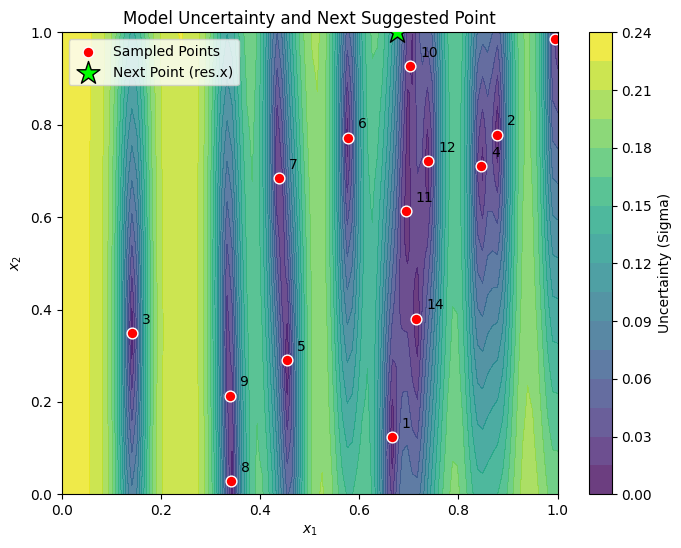

In [17]:
plot_2d_uncertainty(model, X, best_x)


## New Code 17 Feb

In [11]:
# 1. Setup Kernel with wider bounds
Matern_kernel = C(1.0, (1e-3, 1e4)) * Matern(
    length_scale=[0.1, 0.1], 
    length_scale_bounds=(1e-5, 1e5),  # Give it plenty of room
    nu=2.5
) + WhiteKernel(
    noise_level=1e-3, 
    noise_level_bounds=(1e-7, 1e-1)
)

model = GaussianProcessRegressor(
    kernel=Matern_kernel,
    alpha=0, 
    normalize_y=True, 
    n_restarts_optimizer=30 )    # Increased for better convergence

model.fit(X, Y)
print(f"Model Kernel: {model.kernel_}")

Model Kernel: 0.975**2 * Matern(length_scale=[0.05, 1.25], nu=2.5) + WhiteKernel(noise_level=1.54e-07)


Submit this: 0.676233-1.000000


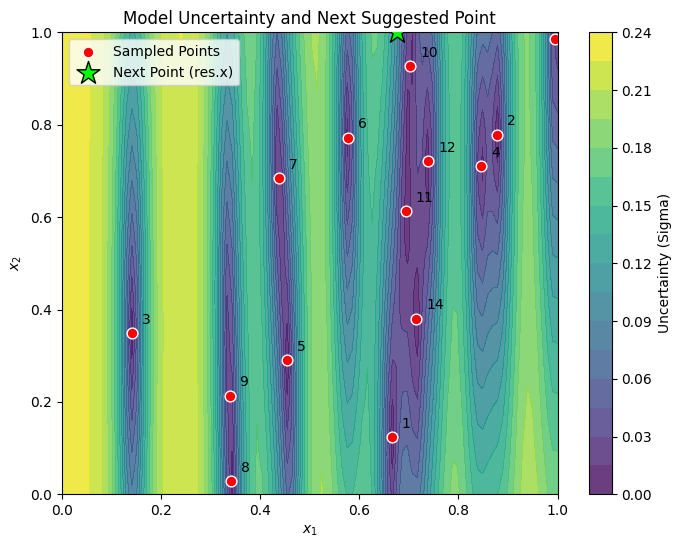

--- Prediction for Next Submission ---
Coordinates: X1=0.676233, X2=1.000000
Predicted Score (Mean): 0.617231
Prediction Uncertainty (Std): 0.095091
95% Confidence Interval: [0.4309, 0.8036]


In [12]:
def expected_improvement(x, model, y_max, xi=0.01):
    x = np.atleast_2d(x)
    mu, sigma = model.predict(x, return_std=True)
    sigma = sigma.reshape(-1, 1)
    
    # Standardize for EI calculation
    with np.errstate(divide='warn'):
        imp = mu - y_max - xi
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return -ei  # Negative for minimization

# Optimization loop logic
y_max = Y.max()
best_acq_value = np.inf
best_x = None

# Use more random starts to find narrow peaks
random_starts = np.random.uniform(0, 1, size=(50, 2))
starting_points = np.vstack([X, random_starts])

for x0 in starting_points:
    res = minimize(expected_improvement, x0=x0, args=(model, y_max),
                   bounds=[(0, 1), (0, 1)], method='L-BFGS-B')
    if res.fun < best_acq_value:
        best_acq_value = res.fun
        best_x = res.x

print(f"Submit this: {'-'.join(f'{v:.6f}' for v in best_x)}")
plot_2d_uncertainty(model, X, best_x)

# prediction
best_x_reshaped = best_x.reshape(1, -1)

# Get both the predicted value and the uncertainty (std)
y_pred_mean, y_pred_std = model.predict(best_x_reshaped, return_std=True)

# Since we used normalize_y=True, the model handles the scaling internally.
# If you want to see the 'Confidence Interval', calculate it here:
lower_bound = y_pred_mean[0] - (1.96 * y_pred_std[0])
upper_bound = y_pred_mean[0] + (1.96 * y_pred_std[0])

print(f"--- Prediction for Next Submission ---")
print(f"Coordinates: X1={best_x[0]:.6f}, X2={best_x[1]:.6f}")
print(f"Predicted Score (Mean): {y_pred_mean[0]:.6f}")
print(f"Prediction Uncertainty (Std): {y_pred_std[0]:.6f}")
print(f"95% Confidence Interval: [{lower_bound:.4f}, {upper_bound:.4f}]")


In [ ]:
results:
Submit this: 0.714914-0.130862
Submit this: 0.714914-0.380302    Predicted Score (Mean): 0.603547   Prediction Uncertainty (Std): 0.035867
Submit this: 0.714914-0.094341    Predicted Score (Mean): 0.603547   Prediction Uncertainty (Std): 0.035867

## New Code 8 Feb

In [16]:
# 1. Setup Kernel with wider bounds
Matern_kernel = C(1.0, (1e-3, 1e4)) * Matern(
    length_scale=[0.1, 0.1], 
    length_scale_bounds=(1e-5, 1e5),  # Give it plenty of room
    nu=2.5
) + WhiteKernel(
    noise_level=1e-3, 
    noise_level_bounds=(1e-7, 1e-1)
)

model = GaussianProcessRegressor(
    kernel=Matern_kernel,
    alpha=0, 
    normalize_y=True, 
    n_restarts_optimizer=30 )    # Increased for better convergence

model.fit(X, Y)
print(f"Model Kernel: {model.kernel_}")

Model Kernel: 1.08**2 * Matern(length_scale=[0.0917, 1.86e+04], nu=2.5) + WhiteKernel(noise_level=0.00973)


Submit this: 0.992387-1.000000


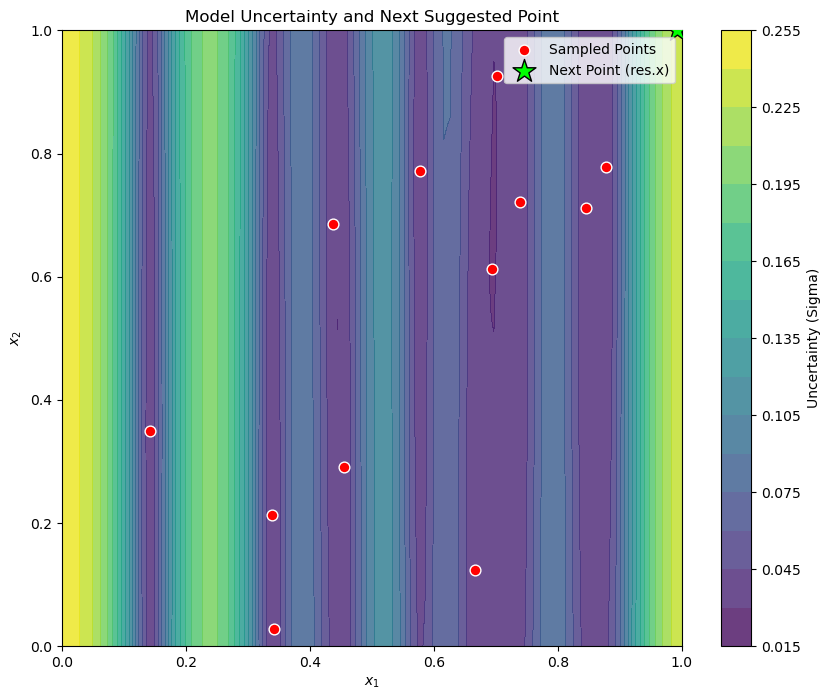

In [14]:
# 2. Define Acquisition Function (UCB)
def ucb_acquisition(x, model, beta=2.5):
    x = np.atleast_2d(x)
    mean, std = model.predict(x, return_std=True)
    return -(mean + beta * std) # Negative for minimization

# 3. Find the next point using multiple random restarts
best_acq_value = np.inf
best_x = None
bounds = [(0, 1), (0, 1)]

# Start from a mix of existing points and random points
starting_points = np.vstack([X, np.random.uniform(0, 1, size=(10, 2))])

for x0 in starting_points:
    res = minimize(ucb_acquisition, x0=x0, args=(model, 1.96),
                   bounds=bounds, method='L-BFGS-B')
    if res.fun < best_acq_value:
        best_acq_value = res.fun
        best_x = res.x

print(f"Submit this: {'-'.join(f'{v:.6f}' for v in best_x)}")
plot_2d_uncertainty(model, X, best_x)

Optimized Kernel: 1.08**2 * Matern(length_scale=[0.0917, 1.86e+04], nu=2.5) + WhiteKernel(noise_level=0.00973)
Submit this: 0.995575-0.985505


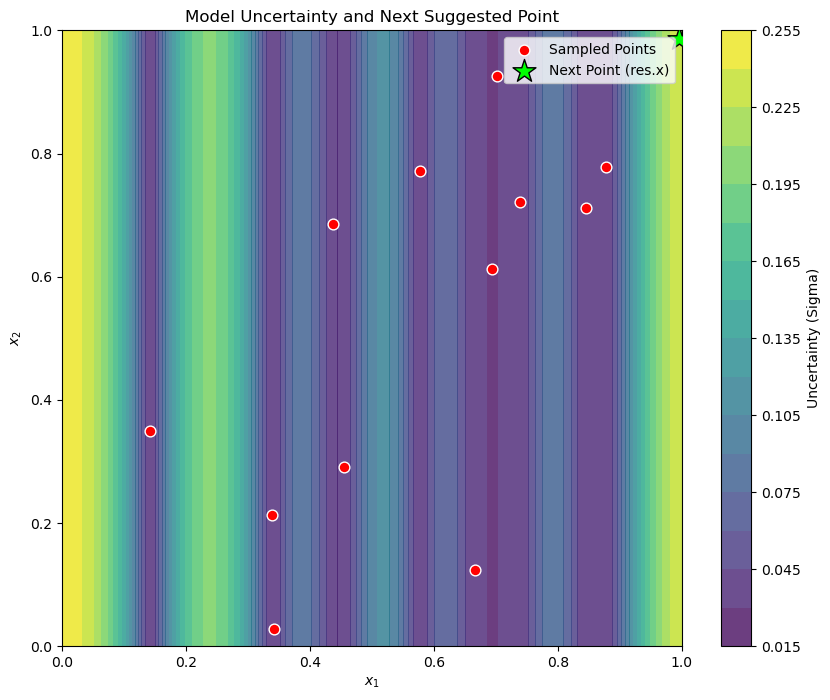

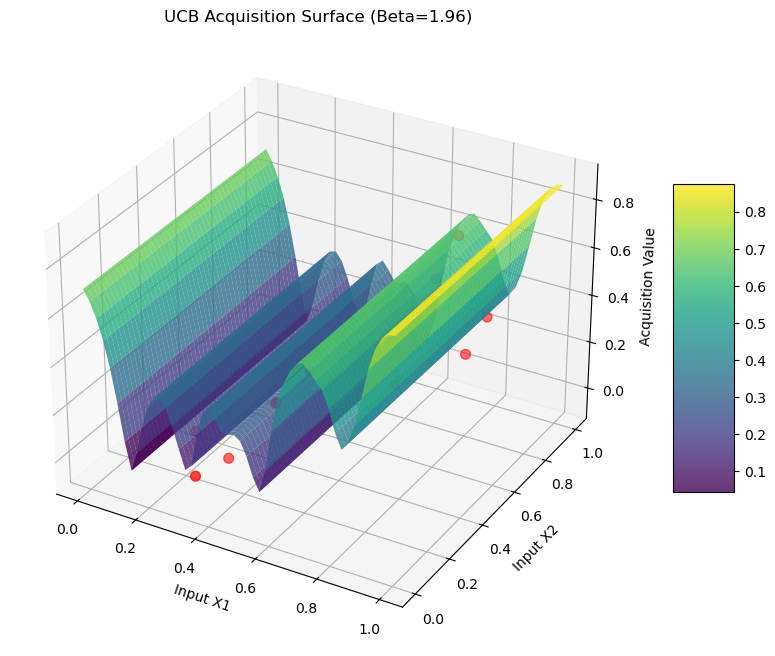

In [21]:
# 2. Define Acquisition Function (UCB)
def ucb_acquisition(x, model, beta=2.5):
    x = np.atleast_2d(x)
    mean, std = model.predict(x, return_std=True)
    return -(mean + beta * std) # Negative for minimization

# 3. Find the next point using multiple random restarts
best_acq_value = np.inf
best_x = None
bounds = [(0, 1), (0, 1)]

# Start from a mix of existing points and random points
starting_points = np.vstack([X, np.random.uniform(0, 1, size=(10, 2))])

for x0 in starting_points:
    res = minimize(ucb_acquisition, x0=x0, args=(model, 1.96),
                   bounds=bounds, method='L-BFGS-B')
    if res.fun < best_acq_value:
        best_acq_value = res.fun
        best_x = res.x

print(f"Optimized Kernel: {model.kernel_}")
print(f"Submit this: {'-'.join(f'{v:.6f}' for v in best_x)}")

plot_2d_uncertainty(model, X, best_x)
plot_acquisition_surface(model)

## Submission results:

Submit this: 0.957621-0.988724
Predicted Y is 3.8070e-01 

New code on 8 Feb:
Submit this: 0.992387-1.000000
Submit this: 0.995575-0.972861
Submit this: 0.995575-0.985505

## Matern Kernel - superceded

In [10]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C

Matern_kernel = C(1.0, (1e-3, 1e4)) * Matern(
    length_scale=[0.5, 0.5], 
    length_scale_bounds=(1e-3, 1e2), # Expanded bounds
    nu=2.5
) + WhiteKernel(
    noise_level=1e-5, 
    noise_level_bounds=(1e-10, 1e-1) # Lower floor for noise
)

# 2. Setup the Regressor
model = GaussianProcessRegressor(
    kernel=Matern_kernel,
    alpha=0,               # Let WhiteKernel handle the noise instead
    normalize_y=True,        # CRITICAL: This scales those tiny e-124 values so the GP can see them
    n_restarts_optimizer=25)   # Gives the optimizer 15 tries to find the best fit
# 3. Fit the model
model.fit(X, Y)
print(f"Optimized Kernel: {model.kernel_}")

Optimized Kernel: 0.897**2 * Matern(length_scale=[0.063, 1], nu=2.5) + WhiteKernel(noise_level=1e-06)


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


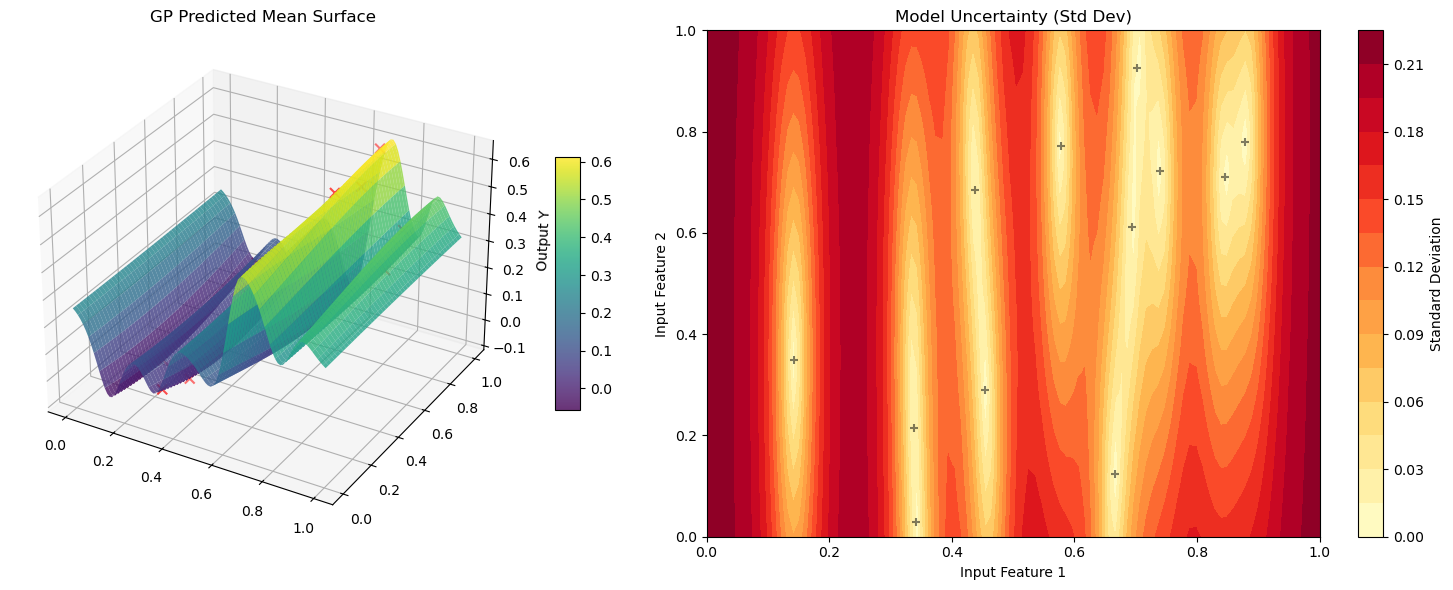

Data so far (sorted by descending observations): 
1: (x, f(x)) = ('0.67, 0.12', '5.3900e-01')
2: (x, f(x)) = ('0.88, 0.78', '4.2059e-01')
3: (x, f(x)) = ('0.14, 0.35', '-6.5624e-02')
4: (x, f(x)) = ('0.85, 0.71', '2.9399e-01')
5: (x, f(x)) = ('0.45, 0.29', '2.1496e-01')
6: (x, f(x)) = ('0.58, 0.77', '2.3106e-02')
7: (x, f(x)) = ('0.44, 0.69', '2.4462e-01')
8: (x, f(x)) = ('0.34, 0.03', '3.8749e-02')
9: (x, f(x)) = ('0.34, 0.21', '-1.3858e-02')
10: (x, f(x)) = ('0.70, 0.93', '6.1121e-01')
11: (x, f(x)) = ('0.69, 0.61', '5.8036e-01')
12: (x, f(x)) = ('0.74, 0.72', '5.6740e-01')
Submit this: 0.957621-0.988724
Predicted Y is 3.8070e-01 


In [11]:
from scipy.optimize import minimize

AcquisitionFunctionBeta = 1.96

# create empty grid to feed in to the model
x1_linspace = np.linspace(0, 1, 100)       # Higher resolution
x2_linspace = np.linspace(0, 1, 100)
X1_grid, X2_grid = np.meshgrid(x1_linspace, x2_linspace)
x_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

post_mean, post_std = model.predict(x_grid, return_std=True)

plot3Dprediction2(X,Y, post_mean, post_std, X1_grid, X2_grid)
# plot3Dprediction(X,Y,model)

# DISPLAY OF X AND Y
#Select a display format for X and Y
# X_format =  ['%.2f' % query[0] + ', %.2f' % query[1] for query in X]  # Format for 2D points
# Y_format = ['%.4e' % obs for obs in Y] #Four sig figs
# data = [(query, obs) for query, obs in zip(X_format, Y_format)]
# print('Data so far (sorted by descending observations): ')
# print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start = 1))) #Display data

# _ = input('Human Input to continue')

# Acquisition function (UCB)
acquisition_function = post_mean + AcquisitionFunctionBeta * post_std


best_index = np.argmax(acquisition_function)
x_next_grid = x_grid[best_index]

# 3. REFINEMENT STEP (Local Optimization)
# Start at the grid's best point and "slide" to the true peak
def objective(x):
    m, s = model.predict(x.reshape(1, -1), return_std=True)
    return -(m[0] + AcquisitionFunctionBeta * s[0])

res = minimize(objective, x0=x_next_grid, bounds=[(0, 1), (0, 1)], method='L-BFGS-B')
#  NOTE: next point to submit is res.x

formatted_submission_string = "-".join(f"{val:.6f}" for val in res.x)
print(f"Submit this: {formatted_submission_string}")

y_predicted = model.predict(res.x.reshape(1, -1))[0]
print(f"Predicted Y is {y_predicted:.4e} ")



## RBF Kernel - IGNORE

In [186]:
# # ########  IGNORE THIS 
# X,Y = load_data()
# # define the kernel, initialise the GP model, train
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF
# rbf_lengthscale = 0.1
# noise_assumption = 1e-8
# # kernel = RBF(length_scale=rbf_lengthscale, length_scale_bounds='fixed')
# RBFkernel = RBF(length_scale=0.1, length_scale_bounds=(1e-2, 1e5))
#                      # length_scale_bounds=(1e-2, 1e3)  = model searches for good value
# model = GaussianProcessRegressor(kernel = RBFkernel, alpha=noise_assumption, n_restarts_optimizer=25)
#                      # n_restarts_optimizer runs the optimization 10 times
# model.fit(X, Y)
# print(f"Optimized Kernel: {model.kernel_}")

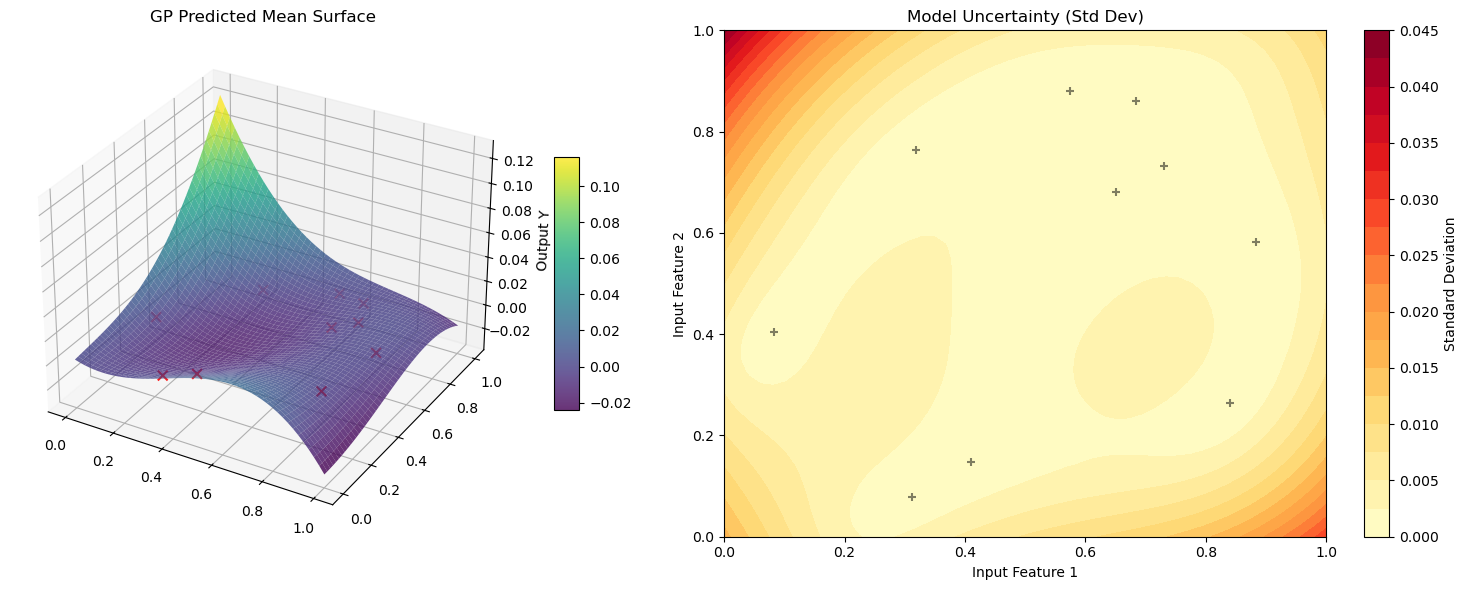

TypeError: only length-1 arrays can be converted to Python scalars

In [61]:
# AcquisitionFunctionBeta = 1.96
# max_obs = -1

# # create empty grid to feed in to the model
# x1_linspace = np.linspace(0, 1, 50)
# x2_linspace = np.linspace(0, 1, 50)
# X1_grid, X2_grid = np.meshgrid(x1_linspace, x2_linspace)
# # Flatten the grid to feed into the model
# x_grid = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

# #Number of queries in the optimisation loop
# num_queries = 1

# for i in range(0, num_queries):
#     clear_output(wait = True)
#     # model = GaussianProcessRegressor(kernel = kernel, alpha=noise_assumption)
#     # model = GaussianProcessRegressor(kernel=RBFkernel,alpha=0, normalize_y=True, n_restarts_optimizer=20)
#     #Fit the model
#     # model.fit(X,Y)
#     #Calculate the mean and standard deviation and make them one-dimensional for plotting
#     post_mean, post_std = model.predict(x_grid, return_std=True)
#     # post_mean, post_std = post_mean.squeeze(), post_std.squeeze()
    
#     #Initialise plots
#     plot3Dprediction2(X,Y,model)
    
#     # DISPLAY OF X AND Y
#     #Select a display format for X and Y
#     X_format = ['%.2f' % query for query in X] #Two sig figs
#     Y_format = ['%.4f' % obs for obs in Y] #Four sig figs
#     data = [(query, obs) for query, obs in zip(X_format, Y_format)]
#     print('Data so far (sorted by descending observations): ')
#     print('\n'.join('{}: (x, f(x)) = {}'.format(*k) for k in enumerate(data, start = 1))) #Display data
    
#     #Initialise x
#     x = -1
#     # _ = input('Input anything to see the next chosen point') #You are using this to allow the user to change plots
    
#     acquisition_function = post_mean + AcquisitionFunctionBeta * post_std
    
#     grid = x_grid.squeeze()
#     x = grid[np.argmax(acquisition_function)]         #  use the acquisition function
#     print("argmax from acquisition_function =",x)

#     best_index = np.argmax(acquisition_function)
#     x_next = grid[best_index]
#     y_predicted = post_mean[best_index]   
#     print(f"The GP predicts the value at {x_next:.4f} will be {y_predicted:.4f}")

#     #Append data, calculate function and sort lists according to observation values
#     X.append(x)
#     y = y_predicted
#     Y.append(y)
#     X = [x for _, x in sorted(zip(Y, X), reverse = True)]
#     Y.sort(reverse = True)
#     max_obs = max(max_obs, y)


## Misc

In [5]:
folder1 = Path(r'C:\Users\Dave Amin\Documents\docs-Sync\Career\2025-10 IC AI course\Modules\Capstone2\initial_data')
folder2 = Path(r'function_2')
file_path_inputs = folder1 / folder2 / "initial_inputs.npy"
print(file_path_inputs)

C:\Users\Dave Amin\Documents\docs-Sync\Career\2025-10 IC AI course\Modules\Capstone2\initial_data\function_2\initial_inputs.npy


In [103]:
num = 1

for i in range(0, num):
    print("count")

count
